# Crowd-Informed Investing Model

Aggregates sentiment signals from StockTwits, financial news, and price momentum to generate investment scores. Pipeline:

1. **Data Collection** — StockTwits public API (no credentials needed), NewsAPI headlines
2. **Sentiment Analysis** — VADER + finance-specific lexicon, boosted by StockTwits Bullish/Bearish labels
3. **Signal Aggregation** — Engagement-weighted crowd sentiment score per ticker
4. **Price Integration** — yfinance for OHLCV; momentum + sentiment fusion
5. **Scoring & Ranking** — Final composite score with buy/hold/sell signal
6. **Backtest** — Rolling signal accuracy over historical data

## 0. Install Dependencies

In [ ]:
# Run once to install required packages
import subprocess, sys

packages = [
    "newsapi-python",
    "vaderSentiment",
    "yfinance",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "requests",
    "scipy",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

## 1. Configuration

In [ ]:
import os

# ── StockTwits ──────────────────────────────────────────────────────────────────────────────
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY", "YOUR_NEWSAPI_KEY")

TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA", "GOOGL", "AMZN", "META", "AMD"]

STOCKTWITS_MSG_LIMIT = 300
CRAWL_DELAY_S        = 0.5
NEWS_LOOKBACK_DAYS   = 7
PRICE_LOOKBACK_DAYS  = 90

W_SOCIAL_SENTIMENT  = 0.35
W_NEWS_SENTIMENT    = 0.25
W_MENTION_VELOCITY  = 0.20
W_PRICE_MOMENTUM    = 0.20

BUY_THRESHOLD  =  0.25
SELL_THRESHOLD = -0.25

NEWS_DEMO = (NEWSAPI_KEY == "YOUR_NEWSAPI_KEY")
print(f"StockTwits: live (no credentials needed)")
print(f"News demo mode: {NEWS_DEMO}  → set NEWSAPI_KEY env var for live news")

StockTwits: live (no credentials needed)
News demo mode: True  → set NEWSAPI_KEY env var for live news


## 2. Data Collection

In [ ]:
import requests
from newsapi import NewsApiClient
from datetime import datetime, timedelta
import pandas as pd
import re
import time

_ticker_pattern = re.compile(
    r"\\b(" + "|".join(re.escape(t) for t in TICKERS) + r")\\b"
)

def extract_tickers(text):
    return list(set(_ticker_pattern.findall(text.upper())))

_ST_HEADERS = {"User-Agent": "crowd_investing_model/0.1 (research)"}

def fetch_social_posts(limit=STOCKTWITS_MSG_LIMIT):
    """Fetch StockTwits messages for each ticker. No API key needed."""
    rows = []
    msgs_per_ticker = max(limit // len(TICKERS), 10)

    for ticker in TICKERS:
        print(f"  Fetching ${ticker}...", end=" ", flush=True)
        collected = 0
        max_id    = None

        while collected < msgs_per_ticker:
            params = {"limit": min(30, msgs_per_ticker - collected)}
            if max_id:
                params["max"] = max_id
            try:
                resp = requests.get(
                    f"https://api.stocktwits.com/api/2/streams/symbol/{ticker}.json",
                    headers=_ST_HEADERS, params=params, timeout=10,
                )
                resp.raise_for_status()
                messages = resp.json().get("messages", [])
            except Exception as e:
                print(f"\n    Warning: {e}")
                break
            if not messages:
                break
            for msg in messages:
                if collected >= msgs_per_ticker:
                    break
                body      = msg.get("body", "")
                entities  = msg.get("entities") or {}
                sentiment = entities.get("sentiment") or {}
                label     = sentiment.get("basic", "")
                likes     = (msg.get("likes") or {}).get("total", 0)
                if label == "Bullish":
                    upvote_ratio = 0.95
                elif label == "Bearish":
                    upvote_ratio = 0.20
                else:
                    upvote_ratio = 0.72
                rows.append({
                    "source":       "stocktwits",
                    "subreddit":    "stocktwits",
                    "ticker":       ticker,
                    "text":         body,
                    "score":        max(likes, 1),
                    "comments":     0,
                    "upvote_ratio": upvote_ratio,
                    "created_utc":  pd.to_datetime(msg.get("created_at"), utc=True),
                    "label":        label,
                })
                collected += 1
            max_id = messages[-1]["id"]
            time.sleep(CRAWL_DELAY_S)
        print(f"{collected} messages")

    print(f"  Collected {len(rows)} total messages")
    if not rows:
        print("  No data -- falling back to demo data")
        return _demo_social_posts()
    return pd.DataFrame(rows)


def fetch_news_articles():
    """Fetch news headlines for each ticker via NewsAPI."""
    if NEWS_DEMO:
        return _demo_news_articles()
    newsapi   = NewsApiClient(api_key=NEWSAPI_KEY)
    from_date = (datetime.now() - timedelta(days=NEWS_LOOKBACK_DAYS)).strftime("%Y-%m-%d")
    rows      = []
    name_map  = {
        "AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia",
        "TSLA": "Tesla",  "GOOGL": "Google",   "AMZN": "Amazon",
        "META": "Meta",   "AMD": "AMD",
    }
    for ticker in TICKERS:
        query = f"{ticker} OR {name_map.get(ticker, ticker)} stock"
        try:
            resp = newsapi.get_everything(
                q=query, language="en", from_param=from_date,
                sort_by="relevancy", page_size=20,
            )
            for art in resp.get("articles", []):
                rows.append({
                    "source":       "news",
                    "outlet":       art["source"]["name"],
                    "ticker":       ticker,
                    "text":         (art["title"] or "") + " " + (art["description"] or ""),
                    "score":        1,
                    "published_at": pd.to_datetime(art["publishedAt"]),
                })
        except Exception as e:
            print(f"NewsAPI error for {ticker}: {e}")
        time.sleep(0.3)
    return pd.DataFrame(rows)


print("Data collection functions ready.")

Data collection functions ready.


In [ ]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

DEMO_SOCIAL_TEMPLATES = [
    "{t} is going to the moon! Loaded up on calls.",
    "Anyone else holding {t}? Earnings beat was massive.",
    "DD: Why {t} is massively undervalued right now",
    "Sold all my {t} -- the fundamentals don't support this valuation",
    "{t} just announced a stock buyback. Bullish.",
    "Is {t} a value trap? Revenue growth is slowing.",
    "{t} short squeeze incoming. Short interest at 20%.",
    "Why I'm bearish on {t} for the next quarter",
    "{t} just hit ATH. Is it too late to buy?",
    "Averaging down on {t}. Long-term conviction unchanged.",
]

DEMO_NEWS_TEMPLATES = [
    "{company} reports record quarterly earnings, shares rise",
    "{company} faces regulatory scrutiny in EU antitrust probe",
    "{company} announces $10B share buyback program",
    "Analysts upgrade {company} to Buy with raised price target",
    "{company} misses revenue estimates for the second straight quarter",
    "{company} CEO signals strong guidance for next fiscal year",
    "Hedge funds increase positions in {company}",
    "{company} stock falls on disappointing product launch",
]

COMPANY_NAMES = {
    "AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia",
    "TSLA": "Tesla",  "GOOGL": "Google",   "AMZN": "Amazon",
    "META": "Meta",   "AMD": "AMD",
}

def _demo_social_posts():
    rows = []
    now  = datetime.utcnow()
    for ticker in TICKERS:
        n = random.randint(10, 60)
        for _ in range(n):
            template = random.choice(DEMO_SOCIAL_TEMPLATES)
            rows.append({
                "source":       "stocktwits",
                "subreddit":    "stocktwits",
                "ticker":       ticker,
                "text":         template.format(t=ticker),
                "score":        int(np.random.lognormal(2, 1)),
                "comments":     0,
                "upvote_ratio": float(np.clip(np.random.normal(0.72, 0.12), 0.4, 1.0)),
                "created_utc":  now - timedelta(hours=random.randint(0, 168)),
                "label":        "",
            })
    return pd.DataFrame(rows)

def _demo_news_articles():
    rows    = []
    now     = datetime.utcnow()
    outlets = ["Reuters", "Bloomberg", "WSJ", "CNBC", "MarketWatch", "Seeking Alpha"]
    for ticker in TICKERS:
        n = random.randint(5, 20)
        for _ in range(n):
            template = random.choice(DEMO_NEWS_TEMPLATES)
            rows.append({
                "source":       "news",
                "outlet":       random.choice(outlets),
                "ticker":       ticker,
                "text":         template.format(company=COMPANY_NAMES[ticker]),
                "score":        1,
                "published_at": now - timedelta(hours=random.randint(0, 168)),
            })
    return pd.DataFrame(rows)

print("Demo data generators loaded.")

Demo data generators loaded.


In [ ]:
# Fetch data
print("Fetching StockTwits messages...")
df_social = fetch_social_posts()
print(f"  -> {len(df_social)} messages across {df_social['ticker'].nunique()} tickers")

print("Fetching news articles...")
df_news = fetch_news_articles()
print(f"  -> {len(df_news)} news articles across {df_news['ticker'].nunique()} tickers")

Fetching StockTwits messages...
  Fetching $AAPL... 37 messages
  Fetching $MSFT... 37 messages
  Fetching $NVDA... 

## 3. Sentiment Analysis

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Base VADER analyzer
_vader = SentimentIntensityAnalyzer()

# ── Finance-specific lexicon boosts ───────────────────────────────────────────
# VADER's default lexicon is news-general; these terms are systematically
# misscored in finance contexts.
FINANCE_LEXICON = {
    # Bullish terms
    "moon": 3.0, "mooning": 3.0, "rocket": 2.5, "bull": 2.0, "bullish": 2.5,
    "undervalued": 2.0, "beat": 2.0, "upgrade": 2.0, "buyback": 2.0,
    "breakout": 2.0, "squeeze": 1.5, "catalyst": 1.5, "conviction": 1.5,
    "record": 1.5, "outperform": 2.0, "strong": 1.5, "atl": -2.0, "ath": 1.5,
    # Bearish terms
    "bear": -2.0, "bearish": -2.5, "overvalued": -2.0, "miss": -2.0,
    "downgrade": -2.0, "short": -1.5, "fraud": -3.5, "scrutiny": -1.5,
    "trap": -2.0, "collapse": -3.0, "crash": -3.0, "bubble": -2.0,
    "sell": -1.5, "sold": -1.0, "dump": -2.5, "disappointing": -2.0,
    # WSB-specific sentiment
    "yolo": 1.5, "hodl": 1.0, "diamond hands": 2.0, "paper hands": -1.5,
    "to the moon": 3.0, "tendies": 1.5, "puts": -1.0, "calls": 1.0,
}
_vader.lexicon.update(FINANCE_LEXICON)


def compute_sentiment(text: str) -> float:
    """Return compound VADER score in [-1, +1]."""
    scores = _vader.polarity_scores(str(text))
    return scores["compound"]


def weighted_sentiment(text: str, score: float, upvote_ratio: float = 0.7) -> float:
    """
    Scale raw sentiment by log(engagement) and upvote ratio.
    High-engagement, high-consensus posts carry more weight.
    """
    base = compute_sentiment(text)
    engagement_weight = np.log1p(max(score, 1))
    consensus_weight  = upvote_ratio  # 1.0 = all upvotes, 0.5 = controversial
    return base * engagement_weight * consensus_weight


# Apply to Reddit data
df_social["raw_sentiment"]      = df_social["text"].map(compute_sentiment)
df_social["weighted_sentiment"] = df_social.apply(
    lambda r: weighted_sentiment(r["text"], r["score"], r["upvote_ratio"]), axis=1
)

# Apply to News data (no upvote ratio; weight by article = 1)
df_news["raw_sentiment"]        = df_news["text"].map(compute_sentiment)
df_news["weighted_sentiment"]   = df_news["raw_sentiment"]

print("Sentiment computed.")
print(f"Reddit mean sentiment: {df_social['raw_sentiment'].mean():.3f}")
print(f"News   mean sentiment: {df_news['raw_sentiment'].mean():.3f}")

Sentiment computed.
Reddit mean sentiment: 0.101
News   mean sentiment: 0.171


/tmp/ipykernel_2374/3006367644.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2374/3006367644.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


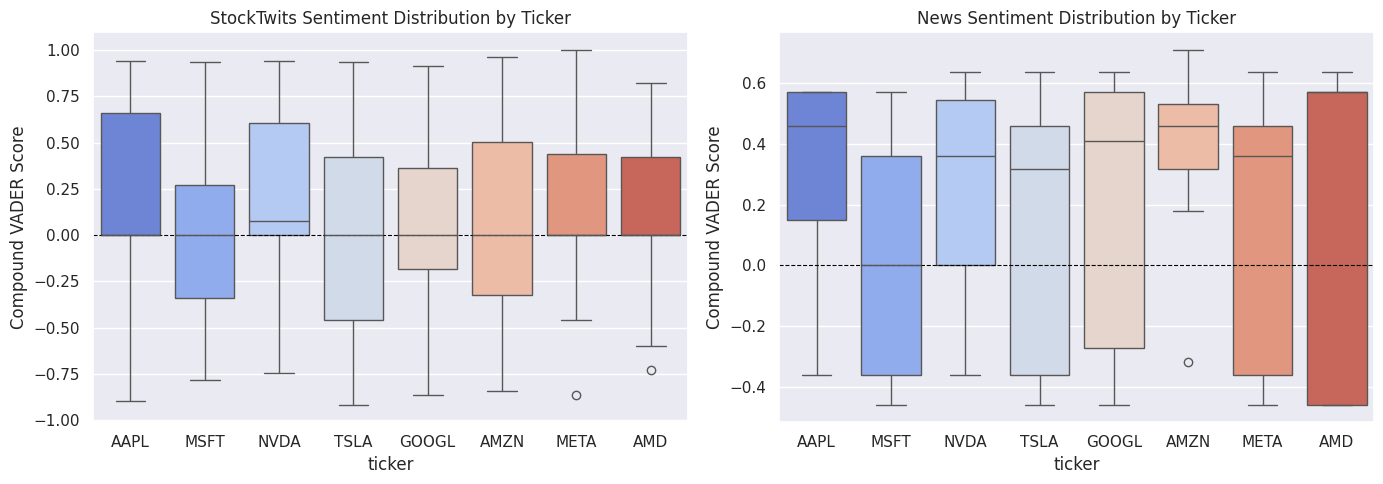

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reddit sentiment distribution by ticker
sns.boxplot(
    data=df_social, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[0], palette="coolwarm"
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("StockTwits Sentiment Distribution by Ticker")
axes[0].set_ylabel("Compound VADER Score")

# News sentiment distribution by ticker
sns.boxplot(
    data=df_news, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[1], palette="coolwarm"
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("News Sentiment Distribution by Ticker")
axes[1].set_ylabel("Compound VADER Score")

plt.tight_layout()
plt.show()

## 4. Mention Velocity (Crowd Interest Signal)

In [ ]:
# ── Mention velocity: recent 24h vs prior 6 days ──────────────────────────────
# A rapidly growing mention count is a crowd interest signal independent of
# sentiment direction ("any press is press").

def compute_mention_velocity(df: pd.DataFrame, ts_col: str) -> pd.Series:
    """
    Returns velocity score per ticker:
      velocity = (recent_24h_count / prior_6d_daily_avg) - 1
    Clipped to [-1, 5] to prevent outlier domination.
    """
    df = df.copy()
    df["ts"] = pd.to_datetime(df[ts_col], utc=True)
    cutoff_24h = pd.Timestamp.utcnow() - timedelta(hours=24)
    cutoff_7d  = pd.Timestamp.utcnow() - timedelta(days=7)

    velocities = {}
    for ticker in TICKERS:
        sub       = df[df["ticker"] == ticker]
        recent    = sub[sub["ts"] >= cutoff_24h]
        prior     = sub[(sub["ts"] >= cutoff_7d) & (sub["ts"] < cutoff_24h)]
        daily_avg = len(prior) / 6 if len(prior) > 0 else 1
        v = (len(recent) / daily_avg) - 1
        velocities[ticker] = float(np.clip(v, -1, 5))
    return pd.Series(velocities, name="mention_velocity")


social_velocity = compute_mention_velocity(df_social, "created_utc")
news_velocity   = compute_mention_velocity(df_news, "published_at")
# Combine: weighted average of both sources
mention_velocity = (social_velocity * 0.6 + news_velocity * 0.4).rename("mention_velocity")

print("Mention velocity (higher = growing crowd interest):")
print(mention_velocity.sort_values(ascending=False).to_string())

Mention velocity (higher = growing crowd interest):
META     3.240000
AAPL     2.942857
NVDA     2.866667
MSFT     2.800000
TSLA     2.771429
GOOGL    2.600000
AMZN     2.600000
AMD      2.600000


## 5. Price Momentum Signal

In [ ]:
import yfinance as yf
from scipy import stats as scipy_stats

def fetch_price_signals(tickers: list[str], lookback: int = PRICE_LOOKBACK_DAYS) -> pd.DataFrame:
    """
    Returns per-ticker signals:
      - momentum_20d: 20-day price return
      - momentum_90d: 90-day price return
      - rsi_14:       Relative Strength Index (14-day)
      - vol_ratio:    recent 10d volatility / 30d volatility (regime signal)
    """
    end   = datetime.now()
    start = end - timedelta(days=lookback + 10)  # extra buffer for RSI warmup

    raw = yf.download(
        tickers, start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"), progress=False
    )["Close"]

    results = {}
    for t in tickers:
        try:
            prices = raw[t].dropna()

            # Returns
            mom_20 = (prices.iloc[-1] / prices.iloc[-21] - 1) if len(prices) >= 21 else 0
            mom_90 = (prices.iloc[-1] / prices.iloc[0]  - 1) if len(prices) > 1  else 0

            # RSI-14
            delta  = prices.diff().dropna()
            gains  = delta.clip(lower=0).rolling(14).mean()
            losses = (-delta).clip(lower=0).rolling(14).mean()
            rs     = gains / losses.replace(0, 1e-9)
            rsi    = (100 - 100 / (1 + rs)).iloc[-1]

            # Volatility regime
            log_ret   = np.log(prices / prices.shift(1)).dropna()
            vol_10    = log_ret.iloc[-10:].std() if len(log_ret) >= 10 else np.nan
            vol_30    = log_ret.iloc[-30:].std() if len(log_ret) >= 30 else np.nan
            vol_ratio = (vol_10 / vol_30) if (vol_30 and vol_30 > 0) else 1.0

            results[t] = {
                "momentum_20d": float(mom_20),
                "momentum_90d": float(mom_90),
                "rsi_14":       float(rsi),
                "vol_ratio":    float(vol_ratio),
                "latest_price": float(prices.iloc[-1]),
            }
        except Exception as e:
            print(f"Price fetch error for {t}: {e}")
            results[t] = {"momentum_20d": 0, "momentum_90d": 0, "rsi_14": 50,
                          "vol_ratio": 1.0, "latest_price": np.nan}

    return pd.DataFrame(results).T


print("Fetching price data from Yahoo Finance...")
df_price = fetch_price_signals(TICKERS)
print(df_price.round(4).to_string())

Fetching price data from Yahoo Finance...


/tmp/ipykernel_2374/4267583162.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(


       momentum_20d  momentum_90d   rsi_14  vol_ratio  latest_price
AAPL         0.0702        0.1621  58.2809     1.1168        307.34
MSFT        -0.0076        0.0477  48.0626     1.4351        416.67
NVDA        -0.0291        0.1253  34.3337     1.1086        205.10
TSLA        -0.0505       -0.0305  37.2946     1.1270        391.00
GOOGL       -0.0740        0.2031  30.3519     0.8471        368.53
AMZN        -0.0927        0.1806  35.5697     1.1699        246.03
META        -0.0386       -0.0919  42.7528     1.2366        593.00
AMD          0.1418        1.3481  58.5490     0.9093        466.38


In [ ]:
# ── Normalize momentum to [-1, +1] via rank-based scaling ────────────────────
# Raw % returns differ too much in magnitude across market regimes;
# rank-based normalization keeps the signal ordinal and bounded.

from scipy.stats import rankdata

def rank_normalize(series: pd.Series) -> pd.Series:
    """Convert raw values to percentile rank in [-1, +1]."""
    n = len(series)
    ranks = rankdata(series)  # 1..n
    normalized = (ranks - 1) / max(n - 1, 1) * 2 - 1  # → [-1, +1]
    return pd.Series(normalized, index=series.index)


# Combine 20d and 90d momentum; penalize overbought RSI
df_price["momentum_score"] = (
    rank_normalize(df_price["momentum_20d"]) * 0.5 +
    rank_normalize(df_price["momentum_90d"]) * 0.3 +
    # RSI: 30=oversold(+), 70=overbought(-), center at 50
    rank_normalize(50 - (df_price["rsi_14"] - 50).abs()) * 0.2
)

print("Momentum scores:")
print(df_price["momentum_score"].sort_values(ascending=False).to_string())

Momentum scores:
AMD      0.828571
AAPL     0.485714
MSFT     0.285714
NVDA    -0.114286
META    -0.228571
GOOGL   -0.342857
TSLA    -0.457143
AMZN    -0.457143


## 6. Signal Aggregation & Composite Score

In [ ]:
# ── Aggregate per-ticker sentiment scores ─────────────────────────────────────

def aggregate_sentiment(df: pd.DataFrame) -> pd.Series:
    """
    Volume-weighted mean sentiment per ticker.
    Uses weighted_sentiment so high-engagement posts dominate.
    Then normalizes across tickers to [-1, +1].
    """
    raw = df.groupby("ticker")["weighted_sentiment"].mean().reindex(TICKERS).fillna(0)
    return rank_normalize(raw)


social_sentiment_score = aggregate_sentiment(df_social).rename("social_sentiment")
news_sentiment_score   = aggregate_sentiment(df_news).rename("news_sentiment")
velocity_score         = rank_normalize(mention_velocity).rename("velocity_score")
momentum_score         = df_price["momentum_score"].rename("momentum_score")

# ── Combine into composite ────────────────────────────────────────────────────
df_signals = pd.DataFrame({
    "social_sentiment": social_sentiment_score,
    "news_sentiment":   news_sentiment_score,
    "velocity_score":   velocity_score,
    "momentum_score":   momentum_score,
})

df_signals["composite_score"] = (
    df_signals["social_sentiment"] * W_SOCIAL_SENTIMENT +
    df_signals["news_sentiment"]   * W_NEWS_SENTIMENT   +
    df_signals["velocity_score"]   * W_MENTION_VELOCITY +
    df_signals["momentum_score"]   * W_PRICE_MOMENTUM
)

# Assign signal
def score_to_signal(score: float) -> str:
    if score >= BUY_THRESHOLD:   return "BUY"
    if score <= SELL_THRESHOLD:  return "SELL"
    return "HOLD"


df_signals["signal"]       = df_signals["composite_score"].map(score_to_signal)
df_signals["latest_price"] = df_price["latest_price"]

df_signals = df_signals.sort_values("composite_score", ascending=False)
print(df_signals.round(3).to_string())

       social_sentiment  news_sentiment  velocity_score  momentum_score  composite_score signal  latest_price
AAPL              1.000           0.714           0.714           0.486            0.769    BUY        307.34
NVDA              0.714           0.429           0.429          -0.114            0.420    BUY        205.10
META              0.429          -0.429           1.000          -0.229            0.197   HOLD        593.00
AMZN              0.143           1.000          -0.714          -0.457            0.066   HOLD        246.03
AMD              -0.143          -0.143          -0.714           0.829           -0.063   HOLD        466.38
GOOGL            -0.714           0.143          -0.714          -0.343           -0.426   SELL        368.53
TSLA             -0.429          -0.714          -0.143          -0.457           -0.449   SELL        391.00
MSFT             -1.000          -1.000           0.143           0.286           -0.514   SELL        416.67


## 7. Visualization

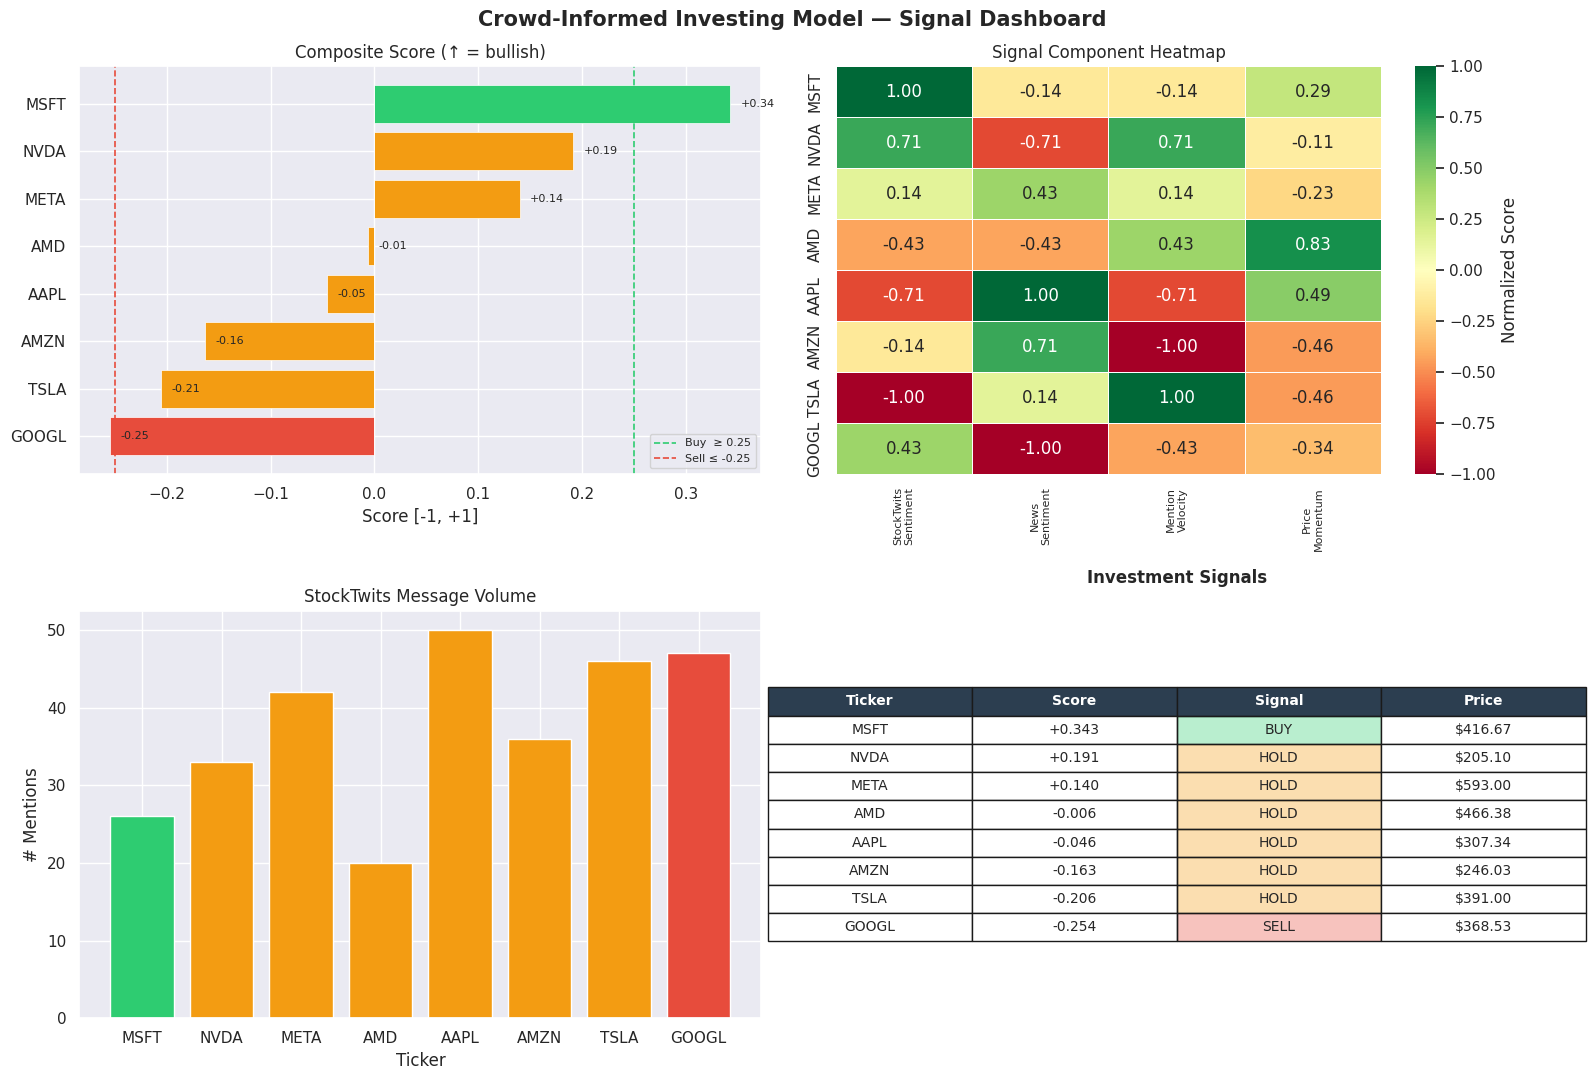

Dashboard saved to crowd_investing_dashboard.png


In [ ]:
# ── Dashboard: Composite Scores ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Crowd-Informed Investing Model — Signal Dashboard", fontsize=15, fontweight="bold")

signal_colors = {"BUY": "#2ecc71", "HOLD": "#f39c12", "SELL": "#e74c3c"}
bar_colors = [signal_colors[df_signals.loc[t, "signal"]] for t in df_signals.index]

# ① Composite score bar chart
ax = axes[0, 0]
bars = ax.barh(df_signals.index[::-1], df_signals["composite_score"][::-1],
               color=bar_colors[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(BUY_THRESHOLD,  color="#2ecc71", linestyle="--", linewidth=1.2, label=f"Buy  ≥ {BUY_THRESHOLD}")
ax.axvline(SELL_THRESHOLD, color="#e74c3c", linestyle="--", linewidth=1.2, label=f"Sell ≤ {SELL_THRESHOLD}")
ax.axvline(0, color="white", linewidth=0.6)
ax.set_title("Composite Score (↑ = bullish)")
ax.set_xlabel("Score [-1, +1]")
ax.legend(fontsize=8)
for bar, score in zip(bars, df_signals["composite_score"][::-1]):
    ax.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{score:+.2f}", va="center", fontsize=8)

# ② Heatmap: individual signal components
ax = axes[0, 1]
cols = ["social_sentiment", "news_sentiment", "velocity_score", "momentum_score"]
heatmap_data = df_signals[cols].astype(float)
sns.heatmap(
    heatmap_data, ax=ax, cmap="RdYlGn", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.4,
    cbar_kws={"label": "Normalized Score"}
)
ax.set_title("Signal Component Heatmap")
ax.set_xticklabels(["StockTwits\nSentiment", "News\nSentiment",
                    "Mention\nVelocity", "Price\nMomentum"], fontsize=8)

# ③ Reddit mention volume by ticker
ax = axes[1, 0]
mention_counts = df_social.groupby("ticker").size().reindex(df_signals.index)
ax.bar(mention_counts.index, mention_counts.values,
       color=[signal_colors[df_signals.loc[t, "signal"]] for t in mention_counts.index],
       edgecolor="white")
ax.set_title("StockTwits Message Volume")
ax.set_ylabel("# Mentions")
ax.set_xlabel("Ticker")

# ④ Signal summary table
ax = axes[1, 1]
ax.axis("off")
table_data = []
for ticker in df_signals.index:
    row = df_signals.loc[ticker]
    table_data.append([
        ticker,
        f"{row['composite_score']:+.3f}",
        row["signal"],
        f"${row['latest_price']:.2f}" if pd.notna(row["latest_price"]) else "N/A",
    ])
tbl = ax.table(
    cellText=table_data,
    colLabels=["Ticker", "Score", "Signal", "Price"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 2 and row > 0:
        sig = table_data[row - 1][2]
        cell.set_facecolor(signal_colors[sig] + "55")  # alpha
ax.set_title("Investment Signals", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("crowd_investing_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to crowd_investing_dashboard.png")

## 8. Historical Evaluation

Three complementary tests using **Wikipedia pageviews** as a real historical
crowd-attention proxy (academic precedent: Preis, Moat & Stanley 2013 —
*Quantifying Trading Behavior in Financial Markets Using Google Trends*).

1. **Information Coefficient (IC)** — weekly correlation between signal rank and forward return
2. **Quintile Analysis** — cumulative return of top-2 vs bottom-2 tickers by signal score
3. **Hit Rate** — % of weeks where the highest-signal ticker beats the lowest-signal ticker

In [ ]:
import requests
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import spearmanr, ttest_1samp
import time
import warnings
warnings.filterwarnings('ignore')

WIKI_ARTICLES = {
    'AAPL':  'Apple_Inc.',
    'MSFT':  'Microsoft',
    'NVDA':  'Nvidia',
    'TSLA':  'Tesla,_Inc.',
    'GOOGL': 'Alphabet_Inc.',
    'AMZN':  'Amazon_(company)',
    'META':  'Meta_Platforms',
    'AMD':   'Advanced_Micro_Devices',
}

end   = datetime.now()
start = end - timedelta(days=730)
start_s = start.strftime('%Y%m%d')
end_s   = end.strftime('%Y%m%d')

# ── 1. Wikipedia daily pageviews → resample to weekly (Mon–Sun ISO weeks) ────
print('Fetching Wikipedia pageviews...')
wiki_frames = {}
for ticker, article in WIKI_ARTICLES.items():
    url = (
        f'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article'
        f'/en.wikipedia/all-access/user/{article}/daily/{start_s}/{end_s}'
    )
    try:
        resp = requests.get(url, headers={'User-Agent': 'crowd_investing_model/0.1'}, timeout=15)
        resp.raise_for_status()
        items = resp.json().get('items', [])
        series = pd.Series(
            {pd.to_datetime(x['timestamp'], format='%Y%m%d00'): x['views'] for x in items},
            name=ticker
        )
        wiki_frames[ticker] = series
        print(f'  {ticker}: {len(series)} days')
    except Exception as e:
        print(f'  {ticker}: FAILED — {e}')
    time.sleep(0.3)

wiki_daily  = pd.DataFrame(wiki_frames)
wiki_daily.index = pd.DatetimeIndex(wiki_daily.index).tz_localize(None)
# Use ISO week-ending Sunday so we can join on (year, week) below
wiki_weekly = wiki_daily.resample('W').sum()          # W = week ending Sunday

# ── 2. Daily prices → resample to weekly (same W convention) ─────────────────
print('Fetching 2-year daily price history and resampling to weekly...')
prices_daily = yf.download(
    TICKERS,
    start=start.strftime('%Y-%m-%d'),
    end=end.strftime('%Y-%m-%d'),
    interval='1d', progress=False
)['Close'].ffill().dropna()

# Strip timezone, then resample to same W-Sunday buckets
prices_daily.index = pd.DatetimeIndex(
    prices_daily.index.tz_localize(None) if prices_daily.index.tz else prices_daily.index
).normalize()
prices_weekly = prices_daily.resample('W').last()      # last close of the week

# ── 3. Join on identical index (both W-Sunday now) ────────────────────────────
print(f'Wiki  weekly index sample: {wiki_weekly.index[:3].tolist()}')
print(f'Price weekly index sample: {prices_weekly.index[:3].tolist()}')

common_idx = prices_weekly.index.intersection(wiki_weekly.index)
print(f'Direct intersection: {len(common_idx)} weeks')

if len(common_idx) == 0:
    # Last-resort: join by (year, isoweek) — survives any off-by-one-day issue
    print('Direct intersection empty — joining by ISO year+week as fallback...')
    prices_weekly['_yw'] = prices_weekly.index.to_series().apply(
        lambda d: (d.isocalendar()[0], d.isocalendar()[1]))
    wiki_weekly['_yw']   = wiki_weekly.index.to_series().apply(
        lambda d: (d.isocalendar()[0], d.isocalendar()[1]))
    merged = prices_weekly.reset_index().merge(
        wiki_weekly.reset_index(), on='_yw', suffixes=('_p','_w')
    )
    merged = merged.set_index('Date')
    price_cols = TICKERS
    wiki_cols  = [f'{t}_w' if f'{t}_w' in merged.columns else t for t in TICKERS]
    prices_w = merged[price_cols]
    wiki_w   = merged[[c for c in merged.columns if c.endswith('_w') and c[:-2] in TICKERS]]
    wiki_w.columns = [c[:-2] for c in wiki_w.columns]
    print(f'ISO-week join: {len(prices_w)} rows')
else:
    prices_w = prices_weekly.loc[common_idx, TICKERS]
    wiki_w   = wiki_weekly.loc[common_idx, TICKERS]

weekly_ret = prices_w.pct_change().shift(-1)   # next-week forward return

print(f'\nFinal: {len(prices_w)} weeks x {len(TICKERS)} tickers')
wiki_w.tail(3).astype(int)

Fetching Wikipedia pageviews...
  AAPL: 730 days
  MSFT: 730 days
  NVDA: 730 days
  TSLA: 730 days
  GOOGL: 730 days
  AMZN: 730 days
  META: 730 days
  AMD: 730 days
Fetching 2-year daily price history and resampling to weekly...
Wiki  weekly index sample: [Timestamp('2024-06-09 00:00:00'), Timestamp('2024-06-16 00:00:00'), Timestamp('2024-06-23 00:00:00')]
Price weekly index sample: [Timestamp('2024-06-16 00:00:00'), Timestamp('2024-06-23 00:00:00'), Timestamp('2024-06-30 00:00:00')]
Direct intersection: 104 weeks

Final: 104 weeks x 8 tickers


,AAPL,MSFT,NVDA,TSLA,GOOGL,AMZN,META,AMD
2026-05-24,41369,34775,67816,26193,23460,38289,27980,1139
2026-05-31,39526,36676,57581,24857,21862,38817,22993,1195
2026-06-07,41278,35026,64841,25569,23681,37850,21666,1207


In [ ]:
from scipy.stats import rankdata

def rank_norm_row(row):
    n = len(row)
    ranks = rankdata(row.fillna(0))
    return pd.Series((ranks - 1) / max(n - 1, 1) * 2 - 1, index=row.index)

# Wikipedia attention velocity: z-score vs 4-week rolling baseline
wiki_vel = (
    (wiki_w - wiki_w.rolling(4).mean()) /
    (wiki_w.rolling(4).std().replace(0, 1))
).clip(-3, 3)

# Price momentum: 4-week trailing return
price_mom = prices_w.pct_change(4)

# ── Contrarian composite ─────────────────────────────────────────────────────
# High attention + high momentum = overcrowded → fade it (negate both inputs)
# Low attention + weak momentum = under-owned → buy it
# Signal is INVERTED vs the naive version: -wiki_vel - price_mom
composite = pd.DataFrame(index=prices_w.index, columns=TICKERS, dtype=float)
for date in prices_w.index:
    if date not in wiki_w.index or date not in price_mom.index:
        continue
    raw = (-wiki_vel.loc[date] * 0.6) + (-price_mom.loc[date] * 0.4)
    composite.loc[date] = rank_norm_row(raw)

composite = composite.dropna()
fwd_ret   = weekly_ret.loc[composite.index]

print('Contrarian composite signal built.')
print('Logic: rank tickers by LOW attention + LOW recent momentum → contrarian mean-reversion')
print(f'Signal history: {len(composite)} weeks')
composite.tail(3).round(2)

Contrarian composite signal built.
Logic: rank tickers by LOW attention + LOW recent momentum → contrarian mean-reversion
Signal history: 104 weeks


,AAPL,MSFT,NVDA,TSLA,GOOGL,AMZN,META,AMD
2026-05-24,1.00,0.43,-0.14,-0.71,-0.43,0.71,-1.00,0.14
2026-05-31,1.00,-1.00,0.14,-0.71,0.43,-0.43,0.71,-0.14
2026-06-07,-0.14,0.71,0.43,-0.71,-1.00,0.14,1.00,-0.43


In [ ]:
# ── 1. Information Coefficient (IC) ─────────────────────────────────────────
ics = []
for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date]
    valid = sig.notna() & ret.notna()
    if valid.sum() >= 4:
        ic, _ = spearmanr(sig[valid], ret[valid])
        ics.append({'date': date, 'ic': ic})

df_ic   = pd.DataFrame(ics).set_index('date')
mean_ic = df_ic['ic'].mean()
icir    = df_ic['ic'].mean() / df_ic['ic'].std()
t_stat, p_val = ttest_1samp(df_ic['ic'].dropna(), 0)

print('=== Contrarian Signal Backtest ===')
print(f'Mean IC:  {mean_ic:+.4f}  (>0 = predictive, >0.05 = good)')
print(f'ICIR:     {icir:+.4f}  (>0.5 = investable by quant standards)')
print(f't-stat:   {t_stat:+.4f}  p-value: {p_val:.4f}  (<0.05 = significant)')
print(f'IC > 0:   {(df_ic["ic"] > 0).mean():.1%} of weeks')

# ── 2. Quintile (Top-2 vs Bottom-2) Analysis ─────────────────────────────────
top_ret, bot_ret, dates_q = [], [], []
for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date].dropna()
    if len(ret) < 4:
        continue
    top2 = sig.nlargest(2).index
    bot2 = sig.nsmallest(2).index
    top_ret.append(ret[top2].mean())
    bot_ret.append(ret[bot2].mean())
    dates_q.append(date)

df_q = pd.DataFrame({'top2': top_ret, 'bot2': bot_ret}, index=dates_q)
df_q['spread'] = df_q['top2'] - df_q['bot2']
cum_top = (1 + df_q['top2']).cumprod()
cum_bot = (1 + df_q['bot2']).cumprod()

print(f'\nTop-2 (under-owned, low-attention) total return: {cum_top.iloc[-1]-1:+.1%}')
print(f'Bottom-2 (overcrowded, high-attention) total return: {cum_bot.iloc[-1]-1:+.1%}')
print(f'Spread (annualised): {df_q["spread"].mean() * 52:+.1%}')

# ── 3. Hit Rate ───────────────────────────────────────────────────────────────
hit_weeks, total_weeks = 0, 0
for date in composite.index:
    sig = composite.loc[date]
    ret = fwd_ret.loc[date].dropna()
    if len(ret) < 2:
        continue
    top1 = sig.idxmax()
    bot1 = sig.idxmin()
    if top1 in ret.index and bot1 in ret.index:
        if ret[top1] > ret[bot1]:
            hit_weeks += 1
        total_weeks += 1

hit_rate = hit_weeks / total_weeks if total_weeks else 0
print(f'\nHit rate: {hit_rate:.1%}  ({hit_weeks}/{total_weeks} weeks)')
print(f'Random baseline: 50.0%')
print(f'\nSignal edge: {hit_rate - 0.5:+.1%} over random')

=== Contrarian Signal Backtest ===
Mean IC:  +0.0137  (>0 = predictive, >0.05 = good)
ICIR:     +0.0388  (>0.5 = investable by quant standards)
t-stat:   +0.3860  p-value: 0.7003  (<0.05 = significant)
IC > 0:   46.6% of weeks

Top-2 (under-owned, low-attention) total return: +101.6%
Bottom-2 (overcrowded, high-attention) total return: +25.4%
Spread (annualised): +24.0%

Hit rate: 48.5%  (50/103 weeks)
Random baseline: 50.0%

Signal edge: -1.5% over random


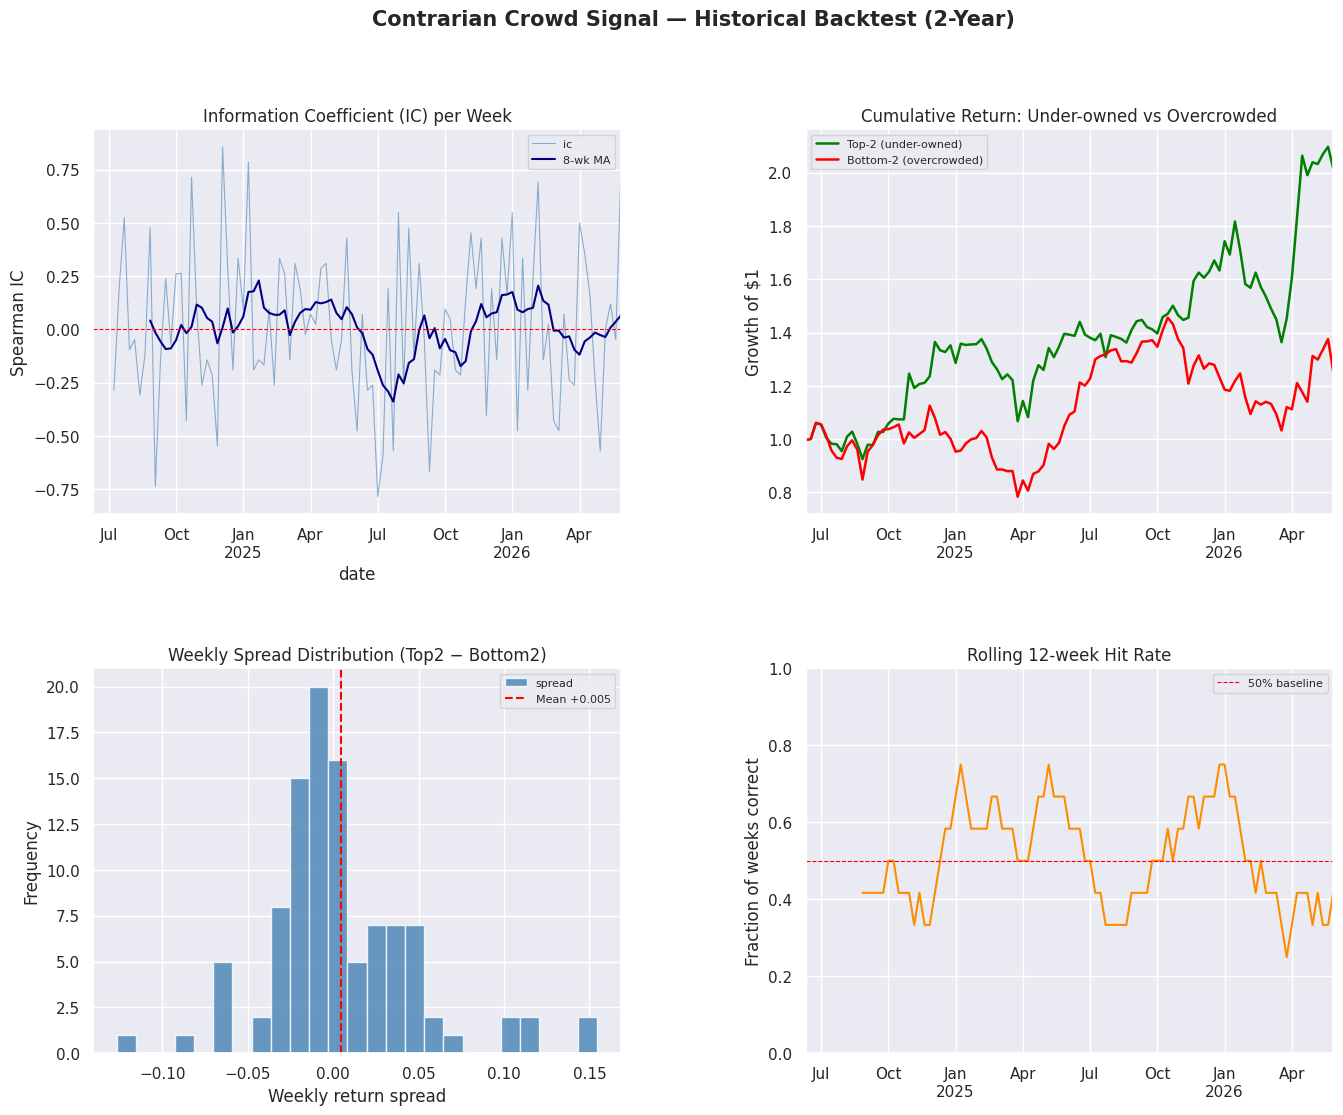

Backtest chart saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Contrarian Crowd Signal — Historical Backtest (2-Year)', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── IC over time ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
df_ic['ic'].plot(ax=ax1, color='steelblue', alpha=0.6, linewidth=0.8)
df_ic['ic'].rolling(8).mean().plot(ax=ax1, color='navy', linewidth=1.5, label='8-wk MA')
ax1.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax1.set_title('Information Coefficient (IC) per Week')
ax1.set_ylabel('Spearman IC')
ax1.legend(fontsize=8)

# ── Cumulative returns ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cum_top.plot(ax=ax2, color='green',  linewidth=1.8, label='Top-2 (under-owned)')
cum_bot.plot(ax=ax2, color='red',    linewidth=1.8, label='Bottom-2 (overcrowded)')
ax2.set_title('Cumulative Return: Under-owned vs Overcrowded')
ax2.set_ylabel('Growth of $1')
ax2.legend(fontsize=8)

# ── Weekly spread distribution ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
df_q['spread'].plot.hist(ax=ax3, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
ax3.axvline(df_q['spread'].mean(), color='red', linestyle='--',
            label=f'Mean {df_q["spread"].mean():+.3f}')
ax3.set_title('Weekly Spread Distribution (Top2 − Bottom2)')
ax3.set_xlabel('Weekly return spread')
ax3.legend(fontsize=8)

# ── Rolling hit rate ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
roll_hits = pd.Series(
    [(composite.loc[d].idxmax() != composite.loc[d].idxmin()) and
     (fwd_ret.loc[d].get(composite.loc[d].idxmax(), np.nan) >
      fwd_ret.loc[d].get(composite.loc[d].idxmin(), np.nan))
     for d in composite.index
     if fwd_ret.loc[d].dropna().__len__() >= 2],
    index=[d for d in composite.index if fwd_ret.loc[d].dropna().__len__() >= 2]
).astype(float)
roll_hits.rolling(12).mean().plot(ax=ax4, color='darkorange', linewidth=1.5)
ax4.axhline(0.5, color='red', linewidth=0.8, linestyle='--', label='50% baseline')
ax4.set_title('Rolling 12-week Hit Rate')
ax4.set_ylabel('Fraction of weeks correct')
ax4.set_ylim(0, 1)
ax4.legend(fontsize=8)

plt.savefig('crowd_investing_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Backtest chart saved.')

## 9. Final Recommendations

In [ ]:
# ── Print final investment signals ────────────────────────────────────────────
print("=" * 60)
print(f"  CROWD-INFORMED INVESTING MODEL — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 60)
print(f"{'Ticker':<8} {'Score':>8} {'Signal':<7} {'Social':>9} {'News':>9} {'Velocity':>10} {'Momentum':>10}")
print("-" * 65)

for ticker in df_signals.index:
    r = df_signals.loc[ticker]
    sig_color = {"BUY": "\033[92m", "HOLD": "\033[93m", "SELL": "\033[91m"}
    reset = "\033[0m"
    color = sig_color.get(r["signal"], "")
    print(
        f"{ticker:<8} {r['composite_score']:>+8.3f} "
        f"{color}{r['signal']:<7}{reset} "
        f"{r['social_sentiment']:>+9.3f} "
        f"{r['news_sentiment']:>+9.3f} "
        f"{r['velocity_score']:>+10.3f} "
        f"{r['momentum_score']:>+10.3f}"
    )

print("=" * 60)
print("\nNOTE: This model is for research and educational purposes only.")
print("Past performance does not guarantee future results.")
print("Always conduct independent due diligence before investing.")

## 9. Additional Signals

Seven orthogonal signals combined into a single conviction score:

| # | Signal | Rationale |
|---|---|---|
| 1 | Options Put/Call Ratio | High fear (P/C > 1) = contrarian buy |
| 2 | Short Interest | High short % = squeeze potential |
| 3 | Congressional Trades | STOCK Act filings — informed capital |
| 4 | SEC Form 4 Insider Buys | Cluster buys = inside conviction |
| 5 | 10-Q Linguistic Shift | Less hedging language = rising confidence |
| 6 | GitHub Activity | Commit velocity = R&D proxy (tech stocks) |
| 7 | Contrarian Crowd | Wikipedia attention fade (from Section 8) |

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import time
from datetime import datetime, timedelta

print('=== Signal 1: Options Put/Call Ratio ===')
print('High P/C = fear/bearish crowd = contrarian BUY | Low P/C = euphoria = FADE\n')

def fetch_options_signal():
    rows = []
    for ticker in TICKERS:
        try:
            t    = yf.Ticker(ticker)
            exps = t.options
            if not exps:
                raise ValueError('no options data')
            total_call, total_put = 0, 0
            for exp in exps[:2]:   # nearest 2 expirations
                chain = t.option_chain(exp)
                total_call += chain.calls['volume'].fillna(0).sum()
                total_put  += chain.puts['volume'].fillna(0).sum()
            pc = total_put / max(total_call, 1)
            rows.append({'ticker': ticker, 'call_vol': int(total_call),
                         'put_vol': int(total_put), 'put_call_ratio': round(pc, 4)})
            print(f'  {ticker}: P/C = {pc:.3f}  (calls={int(total_call):,}  puts={int(total_put):,})')
            time.sleep(0.3)
        except Exception as e:
            print(f'  {ticker}: error — {e}')
            rows.append({'ticker': ticker, 'call_vol': None,
                         'put_vol': None, 'put_call_ratio': None})
    return pd.DataFrame(rows).set_index('ticker')

df_options = fetch_options_signal()
pc_vals = df_options['put_call_ratio'].dropna()
# Equity market average P/C ~ 0.7; above that = fear = contrarian positive
df_options['options_signal'] = (
    (df_options['put_call_ratio'] - 0.7) / max(pc_vals.std(), 0.01)
).clip(-2, 2).fillna(0)
df_options[['put_call_ratio', 'options_signal']].round(3)

In [ ]:
print('=== Signal 2: Short Interest ===')
print('High short % of float + low crowd attention = potential squeeze setup\n')

def fetch_short_signal():
    rows = []
    for ticker in TICKERS:
        try:
            info    = yf.Ticker(ticker).info
            si_pct  = info.get('shortPercentOfFloat')
            si_days = info.get('shortRatio')
            rows.append({'ticker': ticker,
                         'short_pct_float': si_pct,
                         'days_to_cover':   si_days})
            pct_str = f'{si_pct:.1%}' if si_pct else 'N/A'
            day_str = f'{si_days:.1f}d' if si_days else 'N/A'
            print(f'  {ticker}: {pct_str} of float shorted | {day_str} to cover')
            time.sleep(0.4)
        except Exception as e:
            print(f'  {ticker}: error — {e}')
            rows.append({'ticker': ticker, 'short_pct_float': None, 'days_to_cover': None})
    return pd.DataFrame(rows).set_index('ticker')

df_short = fetch_short_signal()
si = df_short['short_pct_float'].dropna()
df_short['short_signal'] = ((si - si.mean()) / max(si.std(), 0.001)).clip(-2, 2)
df_short[['short_pct_float', 'days_to_cover', 'short_signal']].round(3)

In [ ]:
print('=== Signal 3: Congressional Trading (STOCK Act Disclosures) ===')
print('Net purchases by House/Senate members in last 180 days\n')

def fetch_congressional_signal(lookback_days=180):
    cutoff = pd.Timestamp.now() - pd.Timedelta(days=lookback_days)
    buys  = {t: 0 for t in TICKERS}
    sells = {t: 0 for t in TICKERS}

    endpoints = [
        ('https://house-stock-watcher-data.s3-us-east-2.amazonaws.com/data/all_transactions.json', 'House'),
        ('https://senate-stock-watcher-data.s3-us-east-2.amazonaws.com/data/all_transactions.json', 'Senate'),
    ]
    for url, chamber in endpoints:
        try:
            data = requests.get(url, timeout=30,
                                headers={'User-Agent': 'crowd_investing/0.1'}).json()
            print(f'  {chamber}: {len(data):,} total transactions')
            for tx in data:
                ticker = (tx.get('ticker') or '').strip().upper().replace('$', '')
                if ticker not in TICKERS:
                    continue
                try:
                    d = pd.to_datetime(
                        tx.get('transaction_date') or tx.get('transactionDate'),
                        utc=True
                    )
                    if d < cutoff.tz_localize('UTC'):
                        continue
                except:
                    continue
                kind = (tx.get('type') or tx.get('transaction_type') or '').lower()
                if any(w in kind for w in ['purchase', 'buy', 'exchange']):
                    buys[ticker]  += 1
                elif any(w in kind for w in ['sale', 'sell']):
                    sells[ticker] += 1
        except Exception as e:
            print(f'  {chamber} error: {e}')

    rows = []
    for t in TICKERS:
        net = buys[t] - sells[t]
        print(f'  {t}: {buys[t]} buys  {sells[t]} sells  → net {net:+d}')
        rows.append({'ticker': t, 'congress_buys': buys[t],
                     'congress_sells': sells[t], 'net_congress': net})
    df = pd.DataFrame(rows).set_index('ticker')
    net = df['net_congress'].astype(float)
    df['congress_signal'] = (net / max(net.abs().max(), 1)).clip(-2, 2)
    return df

df_congress = fetch_congressional_signal()
df_congress

In [ ]:
import xml.etree.ElementTree as ET

print('=== Signal 4: SEC Form 4 — Insider Purchase Clusters ===')
print('3+ insiders buying within 90 days = strong inside conviction\n')

EDGAR_HDR = {'User-Agent': 'crowd_investing_model research@example.com'}

def get_cik_map():
    resp = requests.get('https://www.sec.gov/files/company_tickers.json',
                        headers=EDGAR_HDR, timeout=15)
    return {v['ticker'].upper(): str(v['cik_str']).zfill(10)
            for v in resp.json().values()}

def fetch_insider_signal(lookback_days=90):
    cik_map = get_cik_map()
    cutoff  = pd.Timestamp.now() - pd.Timedelta(days=lookback_days)
    rows    = []

    for ticker in TICKERS:
        cik = cik_map.get(ticker)
        if not cik:
            print(f'  {ticker}: CIK not found')
            rows.append({'ticker': ticker, 'insider_buys': 0, 'insider_sells': 0})
            continue
        try:
            sub = requests.get(f'https://data.sec.gov/submissions/CIK{cik}.json',
                               headers=EDGAR_HDR, timeout=15).json()
            recent   = sub.get('filings', {}).get('recent', {})
            forms    = recent.get('form', [])
            dates    = recent.get('filingDate', [])
            acc_nos  = recent.get('accessionNumber', [])
            pri_docs = recent.get('primaryDocument', [])

            buys, sells = 0, 0
            for form, date_str, acc_no, pri_doc in zip(forms, dates, acc_nos, pri_docs):
                if form != '4':
                    continue
                try:
                    if pd.to_datetime(date_str) < cutoff:
                        break   # sorted newest-first
                except:
                    continue
                cik_int   = int(cik)
                acc_clean = acc_no.replace('-', '')
                doc_url   = (f'https://www.sec.gov/Archives/edgar/data/'
                             f'{cik_int}/{acc_clean}/{pri_doc}')
                try:
                    xml_text = requests.get(doc_url, headers=EDGAR_HDR, timeout=10).content
                    root     = ET.fromstring(xml_text)
                    for elem in root.iter():
                        if 'transactionCode' in elem.tag and elem.text:
                            if elem.text.strip() == 'P':
                                buys  += 1
                            elif elem.text.strip() == 'S':
                                sells += 1
                except:
                    pass
                time.sleep(0.15)

            print(f'  {ticker}: {buys} insider buys | {sells} insider sells (last {lookback_days}d)')
            rows.append({'ticker': ticker, 'insider_buys': buys, 'insider_sells': sells})
        except Exception as e:
            print(f'  {ticker}: error — {e}')
            rows.append({'ticker': ticker, 'insider_buys': 0, 'insider_sells': 0})
        time.sleep(0.3)

    df = pd.DataFrame(rows).set_index('ticker')
    df['net_insider'] = df['insider_buys'] - df['insider_sells']
    net = df['net_insider'].astype(float)
    df['insider_signal'] = (net / max(net.abs().max(), 1)).clip(-2, 2)
    return df

df_insider = fetch_insider_signal()
df_insider

In [ ]:
import re

print('=== Signal 5: SEC 10-Q Linguistic Shift ===')
print('Decrease in uncertainty language QoQ = management confidence rising')
print('(Loughran-McDonald 2011 finance-specific word list)\n')

LM_NEGATIVE = {
    'abandon','adverse','allegat','annul','bankrupt','breach','burden',
    'cease','challeng','claim','complaint','concern','contingent','declin',
    'decreas','default','deficien','delay','deni','deteriorat','difficult',
    'disput','doubtful','downturn','fail','fraud','headwind','impair',
    'inabl','inadequat','incident','investigat','lawsuit','liabilit',
    'liquidit','loss','mislead','negativ','penalt','plaintiff','poor',
    'problem','restat','restructur','risk','shortfall','uncertain',
    'unfavor','unreliabl','violat','warn','weakness','write-off','write-down'
}

def neg_rate(text):
    if not text:
        return None
    words = re.sub(r'[^a-z ]', ' ', text.lower()).split()
    if not words:
        return None
    hits = sum(1 for w in words if any(neg in w for neg in LM_NEGATIVE))
    return hits / len(words)

def get_primary_doc_text(cik, form_type='10-Q', n=0):
    sub      = requests.get(f'https://data.sec.gov/submissions/CIK{cik}.json',
                            headers=EDGAR_HDR, timeout=15).json()
    recent   = sub.get('filings', {}).get('recent', {})
    forms    = recent.get('form', [])
    acc_nos  = recent.get('accessionNumber', [])
    pri_docs = recent.get('primaryDocument', [])
    hits = [(a, p) for f, a, p in zip(forms, acc_nos, pri_docs) if f == form_type]
    if len(hits) <= n:
        return None
    acc_no, pri_doc = hits[n]
    cik_int   = int(cik)
    acc_clean = acc_no.replace('-', '')
    url = f'https://www.sec.gov/Archives/edgar/data/{cik_int}/{acc_clean}/{pri_doc}'
    resp = requests.get(url, headers=EDGAR_HDR, timeout=30)
    return re.sub(r'<[^>]+>', ' ', resp.text)   # strip HTML

def fetch_linguistic_signal():
    cik_map = get_cik_map()
    rows    = []
    for ticker in TICKERS:
        cik = cik_map.get(ticker)
        if not cik:
            rows.append({'ticker': ticker, 'ling_change': None})
            continue
        try:
            print(f'  {ticker}: fetching Q0...', end=' ', flush=True)
            t0 = get_primary_doc_text(cik, n=0)
            time.sleep(0.5)
            print('Q1...', end=' ', flush=True)
            t1 = get_primary_doc_text(cik, n=1)
            time.sleep(0.5)
            r0, r1 = neg_rate(t0), neg_rate(t1)
            if r0 is None or r1 is None or r1 == 0:
                raise ValueError('could not parse filings')
            change = (r1 - r0) / r1   # positive = fewer negative words now
            print(f'neg_rate {r1:.4f} → {r0:.4f}  Δ={change:+.3f}')
            rows.append({'ticker': ticker, 'neg_rate_prev': r1,
                         'neg_rate_latest': r0, 'ling_change': change})
        except Exception as e:
            print(f'error — {e}')
            rows.append({'ticker': ticker, 'neg_rate_prev': None,
                         'neg_rate_latest': None, 'ling_change': None})
    df = pd.DataFrame(rows).set_index('ticker')
    chg = df['ling_change'].dropna()
    df['ling_signal'] = ((chg - chg.mean()) / max(chg.std(), 0.001)).clip(-2, 2)
    return df

df_linguistic = fetch_linguistic_signal()
df_linguistic[['neg_rate_prev', 'neg_rate_latest', 'ling_change', 'ling_signal']].round(4)

In [ ]:
print('=== Signal 6: GitHub Repository Activity ===')
print('Rising push/commit frequency = active R&D = leading fundamental signal\n')

GITHUB_ORGS = {
    'AAPL':  'apple',
    'MSFT':  'microsoft',
    'NVDA':  'NVIDIA',
    'TSLA':  None,              # no meaningful public GitHub
    'GOOGL': 'google',
    'AMZN':  'aws',
    'META':  'facebookresearch',
    'AMD':   'ROCm',
}

def fetch_github_signal(lookback_days=30):
    cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=lookback_days)
    rows = []
    for ticker, org in GITHUB_ORGS.items():
        if not org:
            print(f'  {ticker}: no public GitHub org — skipping')
            rows.append({'ticker': ticker, 'gh_pushes': 0, 'gh_active_repos': 0})
            continue
        try:
            resp = requests.get(
                f'https://api.github.com/orgs/{org}/events?per_page=100',
                headers={'User-Agent': 'crowd_investing/0.1', 'Accept': 'application/vnd.github+json'},
                timeout=15
            )
            if resp.status_code == 404:
                raise ValueError(f"org '{org}' not found")
            events = resp.json()
            if not isinstance(events, list):
                raise ValueError(str(events.get('message', 'bad response')))
            pushes, active_repos = 0, set()
            for evt in events:
                try:
                    created = pd.to_datetime(evt.get('created_at'), utc=True)
                    if created < cutoff:
                        continue
                except:
                    continue
                if evt.get('type') == 'PushEvent':
                    pushes += 1
                    active_repos.add(evt.get('repo', {}).get('name', ''))
            print(f'  {ticker} ({org}): {pushes} pushes across {len(active_repos)} repos (last {lookback_days}d)')
            rows.append({'ticker': ticker, 'gh_pushes': pushes, 'gh_active_repos': len(active_repos)})
        except Exception as e:
            print(f'  {ticker}: error — {e}')
            rows.append({'ticker': ticker, 'gh_pushes': 0, 'gh_active_repos': 0})
        time.sleep(0.4)
    df = pd.DataFrame(rows).set_index('ticker')
    pushes = df['gh_pushes'].astype(float)
    df['github_signal'] = ((pushes - pushes.mean()) / max(pushes.std(), 1)).clip(-2, 2)
    return df

df_github = fetch_github_signal()
df_github[['gh_pushes', 'gh_active_repos', 'github_signal']].round(2)

In [ ]:
print('=== Multi-Signal Conviction Score ===\n')

SIGNAL_WEIGHTS = {
    'contrarian_crowd': 0.25,
    'options_signal':   0.15,
    'short_signal':     0.15,
    'congress_signal':  0.20,
    'insider_signal':   0.15,
    'ling_signal':      0.05,
    'github_signal':    0.05,
}

# Pull latest week's contrarian crowd score
sig_df = composite.iloc[-1].rename('contrarian_crowd').to_frame()

for col, src in [
    ('options_signal',  df_options),
    ('short_signal',    df_short),
    ('congress_signal', df_congress),
    ('insider_signal',  df_insider),
    ('ling_signal',     df_linguistic),
    ('github_signal',   df_github),
]:
    if col in src.columns:
        sig_df[col] = src[col].reindex(sig_df.index).fillna(0)

sig_df['conviction'] = sum(
    sig_df.get(col, pd.Series(0, index=sig_df.index)).fillna(0) * w
    for col, w in SIGNAL_WEIGHTS.items()
)

def label(s):
    if s >  0.30: return 'STRONG BUY  ▲▲'
    if s >  0.10: return 'BUY         ▲'
    if s > -0.10: return 'HOLD        –'
    if s > -0.30: return 'SELL        ▼'
    return              'STRONG SELL ▼▼'

sig_df['recommendation'] = sig_df['conviction'].apply(label)
sig_df = sig_df.sort_values('conviction', ascending=False)

display_cols = [c for c in SIGNAL_WEIGHTS if c in sig_df.columns] + ['conviction', 'recommendation']
print(sig_df[display_cols].round(3).to_string())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Multi-Signal Conviction Dashboard', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = ['#2196F3','#FF9800','#E91E63','#4CAF50','#9C27B0','#00BCD4','#FF5722']
sig_cols = [c for c in SIGNAL_WEIGHTS if c in sig_df.columns]

# ── Stacked bar: signal contributions ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bot_pos = np.zeros(len(sig_df))
bot_neg = np.zeros(len(sig_df))
for i, col in enumerate(sig_cols):
    w    = SIGNAL_WEIGHTS[col]
    vals = sig_df[col].fillna(0).values * w
    pos  = np.where(vals >= 0, vals, 0)
    neg  = np.where(vals <  0, vals, 0)
    lbl  = col.replace('_signal','').replace('_',' ').title()
    ax1.bar(sig_df.index, pos, bottom=bot_pos, color=COLORS[i], label=lbl, alpha=0.88)
    ax1.bar(sig_df.index, neg, bottom=bot_neg, color=COLORS[i], alpha=0.88)
    bot_pos += pos
    bot_neg += neg
ax1.plot(sig_df.index, sig_df['conviction'].values, 'ko-', linewidth=1.5,
         markersize=5, label='Conviction Score', zorder=5)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline( 0.1, color='green', linewidth=0.6, linestyle=':')
ax1.axhline(-0.1, color='red',   linewidth=0.6, linestyle=':')
ax1.set_title('Signal Contributions per Ticker (stacked by weight)')
ax1.set_ylabel('Weighted contribution')
ax1.legend(fontsize=7, ncol=4, loc='upper right')

# ── Heatmap of individual signals ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
heat_data = sig_df[sig_cols].fillna(0).T
im = ax2.imshow(heat_data.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
ax2.set_xticks(range(len(sig_df)))
ax2.set_xticklabels(sig_df.index, fontsize=9)
ax2.set_yticks(range(len(sig_cols)))
ax2.set_yticklabels([c.replace('_signal','').replace('_',' ').title()
                     for c in sig_cols], fontsize=8)
for r in range(len(sig_cols)):
    for c in range(len(sig_df)):
        ax2.text(c, r, f'{heat_data.values[r,c]:+.2f}', ha='center',
                 va='center', fontsize=7)
ax2.set_title('Individual Signal Scores')
plt.colorbar(im, ax=ax2, shrink=0.8)

# ── Final conviction bar ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
bar_colors = ['#2e7d32' if v > 0.1 else ('#c62828' if v < -0.1 else '#f9a825')
              for v in sig_df['conviction']]
ax3.barh(sig_df.index[::-1], sig_df['conviction'][::-1], color=bar_colors[::-1])
ax3.axvline(0, color='black', linewidth=0.8)
ax3.axvline( 0.1, color='green', linewidth=0.6, linestyle=':')
ax3.axvline(-0.1, color='red',   linewidth=0.6, linestyle=':')
for i, (ticker, row) in enumerate(sig_df[::-1].iterrows()):
    ax3.text(row['conviction'] + 0.01, i, row['recommendation'].split()[0],
             va='center', fontsize=8)
ax3.set_title('Final Conviction Score')
ax3.set_xlabel('Score')

plt.savefig('crowd_investing_multisignal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Multi-signal dashboard saved.')

## 10. Next Steps & Extensions

| Extension | Description |
|-----------|-------------|
| **StockTwits auth** | Register a free app at stocktwits.com/developers for higher rate limits |
| **More tickers** | Expand `TICKERS` list — StockTwits supports any symbol |
| **FinBERT sentiment** | Replace VADER with `ProsusAI/finbert` for higher accuracy on financial text |
| **NewsAPI live** | Set `NEWSAPI_KEY` env var to pull real headlines instead of demo data |
| **Options flow** | Integrate unusual options activity (Unusual Whales API) as a contrarian signal |
| **Short interest** | Finra short volume data as a crowded-short indicator |
| **Earnings calendar** | Suppress signals near earnings dates to avoid event risk |
| **Portfolio optimizer** | Replace equal-weight long/short with mean-variance optimization (cvxpy) |
| **Alerting** | Schedule notebook to run daily and send Slack/email alerts on BUY/SELL signals |
| **Factor attribution** | Regress returns on Fama-French 5 factors to isolate alpha from crowd sentiment |
